# Lab 2-2

## 实验描述

利用大语言模型来检测应用政策文件与安全需求之间的一致性。

实验参考：https://github.com/nghiempt/llm-analysis-privacy-policy

## 实验步骤

### 步骤0: 请记得利用conda进行python环境管理，并在环境中安装 requirements.txt 文件中的包！

### 步骤一：用大语言模型完成一致性检测

In [1]:
# 设置代理
import os

os.environ["http_proxy"]  = 'http://127.0.0.1:10809'
os.environ["https_proxy"]  = 'http://127.0.0.1:10809'


In [1]:
import csv
import os
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline


class HANDLER:
    # Load the model and tokenizer
    model = AutoModelForCausalLM.from_pretrained(
        "microsoft/Phi-3-mini-4k-instruct",
        torch_dtype="auto",
        trust_remote_code=True,
    )
    tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

    # Create the pipeline
    generator = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        return_full_text=False,
        max_new_tokens=500,
        do_sample=False
    )

    @staticmethod
    def remove_empty_lines(content):
        lines = content.split("\n")
        cleaned_lines = [line.strip() for line in lines if line.strip()]
        return "\n".join(cleaned_lines)

    @staticmethod
    def ask_gpt(data_safety_content, privacy_policy_content):
        print('''Let's compare and analyze the information between Data Safety and Privacy Policy to clarify 3 issues: which information is incorrect, which information is incomplete and which information is inconsistent. Notes when classifying: Incomplete: Data Safety provides information but is not as complete as the Privacy Policy provides. Incorrect: Data Safety does not provide that information, but the Privacy Policy mentions it. Inconsistency: Data Safety is provided but its description is inconsistent with the Privacy Policy information provided. Note: always gives me the result (0 or 1, 1 is yes, 0 is no) in the form below: {"incorrect": (0 or 1), "incomplete": (0 or 1), "inconsistent": (0 or 1)}. Please in the answer, just give me the json only and in English. Below is information for 2 parts:\nData Safety: ''' + data_safety_content + '''\nPrivacy Policy:\n''' + privacy_policy_content + ''' ''')

        # Prepare the messages
        messages = [
            {"role": "user", "content": '''Let's compare and analyze the information between Data Safety and Privacy Policy to clarify 3 issues: which information is incorrect, which information is incomplete and which information is inconsistent. Notes when classifying: Incomplete: Data Safety provides information but is not as complete as the Privacy Policy provides. Incorrect: Data Safety does not provide that information, but the Privacy Policy mentions it. Inconsistency: Data Safety is provided but its description is inconsistent with the Privacy Policy information provided. Note: always gives me the result (0 or 1, 1 is yes, 0 is no) in the form below: {"incorrect": (0 or 1), "incomplete": (0 or 1), "inconsistent": (0 or 1)}. Please in the answer, just give me the json only and in English. Below is information for 2 parts:\nData Safety: ''' + data_safety_content + '''\nPrivacy Policy:\n''' + privacy_policy_content + ''' '''}
        ]

        # Generate output using Hugging Face model
        output = HANDLER.generator(messages)
        return output[0]["generated_text"]

    @staticmethod
    def loop_csv(input_csv_path, output_csv_path):
        with open(input_csv_path, "r", newline="", encoding="utf-8") as csvfile, open(
            output_csv_path, "w", newline="", encoding="utf-8"
        ) as outputfile:

            reader = csv.reader(csvfile)
            writer = csv.writer(outputfile)

            headers = next(reader)
            writer.writerow(headers)

            for index, row in enumerate(reader):
                print(
                    "\n_____________ Run times "
                    + str(index + 1)
                    + " <"
                    + row[0]
                    + "> "
                    + "_____________"
                )
                gpt_result = HANDLER().ask_gpt(row[4], row[5])
                row[headers.index("result")] = HANDLER().remove_empty_lines(
                    gpt_result
                )
                writer.writerow(row)
                print("~~~~~~~~~~~~~~ Success ~~~~~~~~~~~~~~\n")



`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use mps:0


### 步骤二：加载文件进行一致性判断

In [2]:
input_csv_path = "data/example.csv"
output_csv_path = "results/example_results.csv"

HANDLER().loop_csv(input_csv_path, output_csv_path)


The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.
`get_max_cache()` is deprecated for all Cache classes. Use `get_max_cache_shape()` instead. Calling `get_max_cache()` will raise error from v4.48



_____________ Run times 1 <1> _____________
Let's compare and analyze the information between Data Safety and Privacy Policy to clarify 3 issues: which information is incorrect, which information is incomplete and which information is inconsistent. Notes when classifying: Incomplete: Data Safety provides information but is not as complete as the Privacy Policy provides. Incorrect: Data Safety does not provide that information, but the Privacy Policy mentions it. Inconsistency: Data Safety is provided but its description is inconsistent with the Privacy Policy information provided. Note: always gives me the result (0 or 1, 1 is yes, 0 is no) in the form below: {"incorrect": (0 or 1), "incomplete": (0 or 1), "inconsistent": (0 or 1)}. Please in the answer, just give me the json only and in English. Below is information for 2 parts:
Data Safety: {'data_shared': [], 'data_collected': [], 'security_practices': [{'category': 'Data is encrypted in transit', 'sub_info': []}, {'category': 'Dat

You are not running the flash-attention implementation, expect numerical differences.


~~~~~~~~~~~~~~ Success ~~~~~~~~~~~~~~


_____________ Run times 2 <2> _____________
Let's compare and analyze the information between Data Safety and Privacy Policy to clarify 3 issues: which information is incorrect, which information is incomplete and which information is inconsistent. Notes when classifying: Incomplete: Data Safety provides information but is not as complete as the Privacy Policy provides. Incorrect: Data Safety does not provide that information, but the Privacy Policy mentions it. Inconsistency: Data Safety is provided but its description is inconsistent with the Privacy Policy information provided. Note: always gives me the result (0 or 1, 1 is yes, 0 is no) in the form below: {"incorrect": (0 or 1), "incomplete": (0 or 1), "inconsistent": (0 or 1)}. Please in the answer, just give me the json only and in English. Below is information for 2 parts:
Data Safety: {'data_shared': [], 'data_collected': [], 'security_practices': [{'category': 'Data is encrypted in trans

## 步骤三：处理输出结果

In [4]:
import pandas as pd
import json

df = pd.read_csv('results/example_results.csv')

def extract_result_values(result):
    result_dict = json.loads(result.replace("'", "\""))
    return pd.Series([result_dict.get('incorrect', 0), result_dict.get('incomplete', 0), result_dict.get('inconsistent', 0)])

df[['incorrect', 'incomplete', 'inconsistent']] = df['result'].apply(extract_result_values)

df = df.drop(columns=['result'])

df.to_csv('results/example_results_processed.csv', index=False)

print("CSV file has been successfully created.")

CSV file has been successfully created.


### 步骤四：分析实验结果

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt

import matplotlib_zh

matplotlib_zh.configure_matplotlib_chinese_font()

actual_data = pd.read_csv("data/example_groudtruth.csv")
predict_data = pd.read_csv("results/example_results_processed.csv")

actual_data = actual_data[["incorrect", "incomplete", "inconsistent"]]
predict_data = predict_data[["incorrect", "incomplete", "inconsistent"]]


for column in actual_data.columns:
    cm = confusion_matrix(actual_data[column], predict_data[column])

    precision = precision_score(actual_data[column], predict_data[column])
    recall = recall_score(actual_data[column], predict_data[column])
    f1 = f1_score(actual_data[column], predict_data[column])
    accuracy = accuracy_score(actual_data[column], predict_data[column])

    print(f"========== {column}:")
    print(cm)
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1: {f1:.3f}")
    print(f"Accuracy: {accuracy:.3f}")
    print()

========== incorrect:
[[2]]
Precision: 1.000
Recall: 1.000
F1: 1.000
Accuracy: 1.000

========== incomplete:
[[2]]
Precision: 1.000
Recall: 1.000
F1: 1.000
Accuracy: 1.000

========== inconsistent:
[[0 2]
 [0 0]]
Precision: 0.000
Recall: 0.000
F1: 0.000
Accuracy: 0.000



/Users/hako/anaconda3/envs/lab/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/hako/anaconda3/envs/lab/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/hako/anaconda3/envs/lab/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 步骤五：实验结果可视化

/Users/hako/anaconda3/envs/lab/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


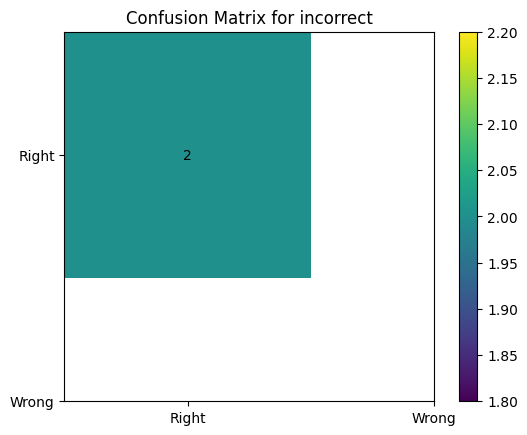

/Users/hako/anaconda3/envs/lab/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


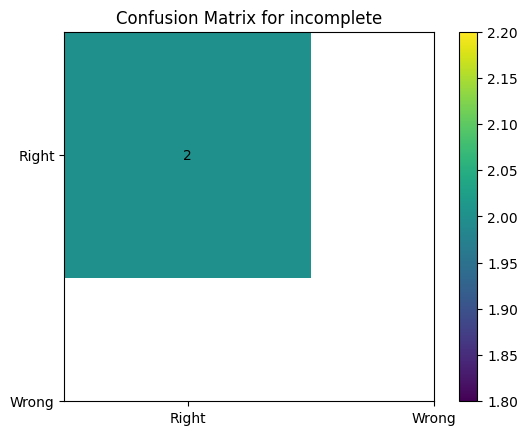

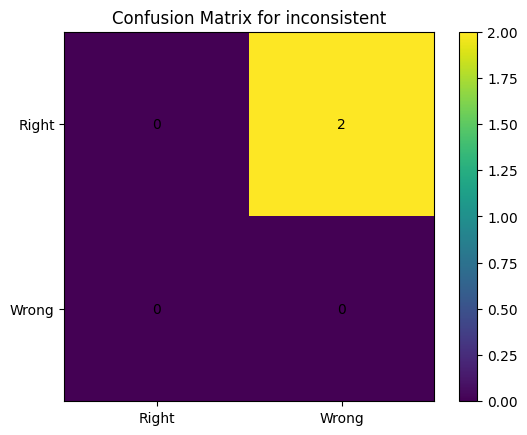

In [9]:
import matplotlib.pyplot as plt

import matplotlib_zh

matplotlib_zh.configure_matplotlib_chinese_font()


def plot_confusion_matrix(cm, title):
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()

    classes = ['Right', 'Wrong']
    plt.xticks(range(len(classes)), classes)
    plt.yticks(range(len(classes)), classes)

    for i in range(len(cm)):
        for j in range(len(cm[0])):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.show()

for column in actual_data.columns:
    cm = confusion_matrix(actual_data[column], predict_data[column])
    plot_confusion_matrix(cm, f"Confusion Matrix for {column}")